Trying out Shap : First Iteration Model


In [27]:
import xgboost 
import pickle
import pandas as pd
# import matplotlib
import matplotlib.pyplot as plt

# Load the model
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)
    
# with open("gridxgb_model.pkl", "wb") as f:
#     model2 = pickle.load(f)
    
# with open("rf_model.pkl", "wb") as f:
#     model2 = pickle.load(f)

In [28]:
import shap

# Create explainer for tree-based models
explainer = shap.TreeExplainer(model)
# explainer_rf = shap.TreeExplainer(model2)

In [29]:
# Calculate SHAP values for test set
test_df = pd.read_csv('test.csv')
X_test = test_df.drop(columns=["TenYearCHD", "stratify"])
shap_values = explainer.shap_values(X_test)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value = explainer.expected_value
# expected_value_rf = explainer_rf.expected_value 

male                 0.00
age                 43.00
currentSmoker        1.00
cigsPerDay          15.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         0.00
diabetes             0.00
totChol            199.00
sysBP              137.00
diaBP               81.00
BMI                 21.85
heartRate           70.00
glucose             72.00
Name: 26, dtype: float64


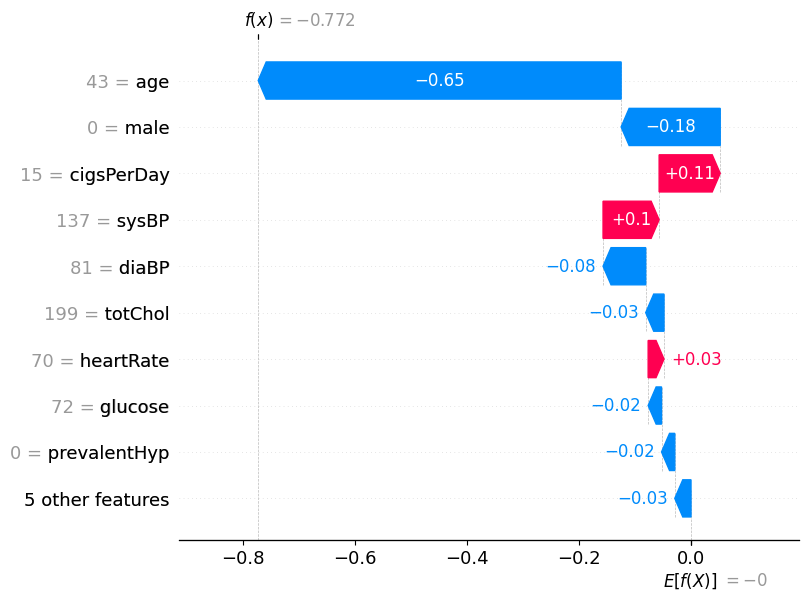

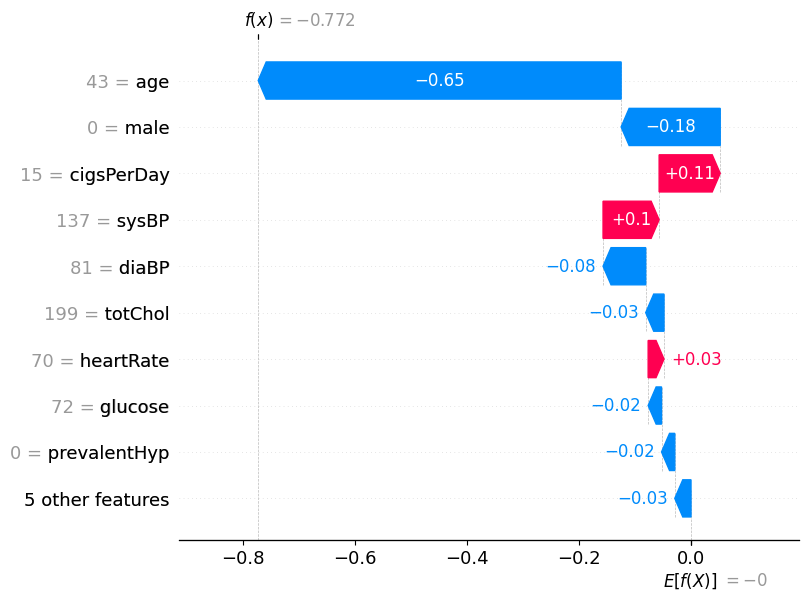

In [ ]:
# Summary plot (global feature importance)
# shap.summary_plot(shap_values, X_test)

# # Beeswarm plot (more detailed)
# shap.summary_plot(shap_values, X_test, plot_type="dot")

# Waterfall plot for single patient (first test patient)
male_patient = X_test.iloc[70]
female_patient = male_patient.copy()

female_patient['male'] = 0

created_pair = pd.DataFrame([male_patient, female_patient])
print(male_patient)
shap_values_pair = explainer.shap_values(created_pair)



shap.waterfall_plot(shap.Explanation(
    values=shap_values_pair[0],
    base_values=expected_value,
    data=created_pair.iloc[0],
    feature_names=X_test.columns.tolist()
))

shap.waterfall_plot(shap.Explanation(
    values=shap_values_pair[1],
    base_values=expected_value,
    data=created_pair.iloc[1],
    feature_names=X_test.columns.tolist()
))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_rf[28],
#     base_values=expected_value_rf,
#     data=X_test.iloc[28],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values[100],
#     base_values=expected_value,
#     data=X_test.iloc[100],
#     feature_names=X_test.columns.tolist()
# ))